In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # para gráficos 3D

# Gráficos vectoriales
import matplotlib_inline.backend_inline
import torch
import torch.nn as nn
import torch.nn.functional as F

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

/tmp/ipykernel_2232/3571636186.py:60: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


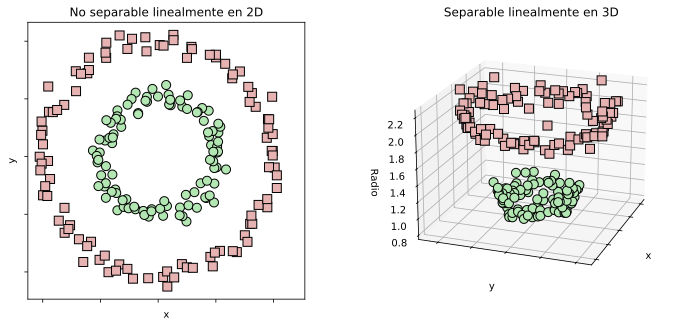

In [2]:
# Ángulos
n = 100
theta = np.linspace(0, 2 * np.pi - 1 / n, n)

# Coordenadas en 2D
x_inner = 1 * np.cos(theta) + np.random.randn(n) / 10
y_inner = 1 * np.sin(theta) + np.random.randn(n) / 10
x_outer = 2 * np.cos(theta) + np.random.randn(n) / 10
y_outer = 2 * np.sin(theta) + np.random.randn(n) / 10

# Expansión de dimensionalidad mediante transformación no lineal
z_inner = np.sqrt(x_inner**2 + y_inner**2)
z_outer = np.sqrt(x_outer**2 + y_outer**2)


### Gráfico de dispersión 2D
fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(121)

ax0.plot(x_inner, y_inner, 'ko', markerfacecolor=[0.7, 0.9, 0.7], markersize=9)
ax0.plot(x_outer, y_outer, 'ks', markerfacecolor=[0.9, 0.7, 0.7], markersize=9)
ax0.axis('square')
ax0.set(
    title='No separable linealmente en 2D',
    xlabel='x',
    ylabel='y',
    xticklabels=[],
    yticklabels=[],
)

### Gráfico de dispersión 3D
ax1 = fig.add_subplot(122, projection='3d')
ax1.plot(
    x_inner,
    y_inner,
    z_inner,
    'ko',
    markerfacecolor=[0.7, 0.9, 0.7],
    markersize=9,
)
ax1.plot(
    x_outer,
    y_outer,
    z_outer,
    'ks',
    markerfacecolor=[0.9, 0.7, 0.7],
    markersize=9,
)
ax1.set(
    title='Separable linealmente en 3D',
    xlabel='x',
    ylabel='y',
    zlabel='Radio',
    xticklabels=[],
    yticklabels=[],
)
ax1.view_init(20, 20)


plt.tight_layout()
plt.show()

#  Intuición Geométrica: Expansión y Contracción Dimensional

La imagen ilustra de forma visual y exacta el **porqué las redes neuronales (como la subcapa MLP de un Transformer) expanden la dimensión a un espacio superior y luego la contraen**.

---

## 1. El Problema en 2D: No Separabilidad Lineal (Gráfico Izquierdo)

* **Espacio Original ($\mathbb{R}^2$):** Tenemos dos categorías de datos descritas únicamente por dos coordenadas $(x, y)$:
  * 🟢 Círculos verdes (clase interna).
  * 🌸 Cuadrados rosados (anillo externo).
* **El Límite del Álgebra Lineal:** No existe ninguna línea recta ($ax + by + c = 0$) capaz de separar los círculos de los cuadrados.
* **Resultado:** Un clasificador puramente lineal (como una regresión logística o una capa lineal simple sin trucos) fracasa, ya que el patrón es **intrínsecamente no lineal**.

---

## 2. La Expansión Dimensional + No-Linealidad (Gráfico Derecho)

Para resolverlo usando operaciones lineales simples, aplicamos una **expansión a una tercera dimensión ($z$) mediante una transformación no lineal**:

$$z = \text{Radius} = \sqrt{x^2 + y^2}$$

### ¿Qué ocurre al "levantar" los datos a 3D?
1. **Diferenciación por Altura:**
   * Los puntos verdes están cerca del origen $\rightarrow$ su radio es pequeño ($z \approx 1.0 - 1.4$).
   * Los puntos rosados están lejos del origen $\rightarrow$ su radio es grande ($z \approx 1.8 - 2.2$).
2. **Separación Lineal Perfecta:** En $\mathbb{R}^3$, los datos ya no están atrapados en el plano. Ahora un simple **plano horizontal** (un hiperplano lineal, por ejemplo en $z = 1.6$) corta limpiamente el espacio y separa ambas clases al $100\%$.

> **Conclusión de la Expansión:** Al proyectar datos a un espacio de mayor dimensionalidad a través de una función no lineal, **las relaciones complejas y no lineales se desenredan y se vuelven linealmente separables**.

---

## 3. ¿Cómo se traduce esto a la subcapa MLP del Transformer?

Este mismo principio geométrico es el que ejecuta la secuencia **$W_1 \to \text{GELU} \to W_2$** en cada bloque del Transformer:

In [3]:
# Bloque Transformer

## Hyperparametros

Solo vamos a setear unos parametros para el bloque de transformer no el modelo completo

In [5]:
# Hiperparámetros de datos
seq_len = 8

# Hiperparámetros del modelo
embed_dim = 128

# Hiperparámetros de entrenamiento
batch_size = 5

## Un cabezal de atención

In [6]:
# Crear un cabezal de atención
class OneAttentionHead(nn.Module):

  def __init__(self, embed_dim):
    super().__init__()

    # Crear las matrices k/q/v
    self.key = nn.Linear(embed_dim, embed_dim, bias=False)
    self.query = nn.Linear(embed_dim, embed_dim, bias=False)
    self.value = nn.Linear(embed_dim, embed_dim, bias=False)
    self.W0 = nn.Linear(embed_dim, embed_dim, bias=False)

  def forward(self, x):

    # Pasar los vectores de embeddings de tokens por la atención
    k = self.key(x)
    q = self.query(x)
    v = self.value(x)
    y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
    y = self.W0(y)  # Ponderaciones lineales post-atención

    return y

In [7]:
# Explorar el cabezal de atención
onehead = OneAttentionHead(embed_dim)

print(onehead)

# Pasar algunos datos simulados
tokenEmbeds = torch.randn(batch_size, seq_len, embed_dim)
out = onehead(tokenEmbeds)
print(f'\nSalida ({out.shape}): \n{out}')

OneAttentionHead(
  (key): Linear(in_features=128, out_features=128, bias=False)
  (query): Linear(in_features=128, out_features=128, bias=False)
  (value): Linear(in_features=128, out_features=128, bias=False)
  (W0): Linear(in_features=128, out_features=128, bias=False)
)

Salida (torch.Size([5, 8, 128])): 
tensor([[[ 1.1970e-01, -4.0862e-01,  4.2369e-01,  ...,  4.3231e-01,
           1.4367e-01, -6.4421e-01],
         [-3.8719e-02,  1.0118e-01,  5.1068e-01,  ...,  4.0151e-01,
           1.3880e-01, -5.0903e-01],
         [ 8.0795e-02, -1.5139e-01,  3.2404e-01,  ...,  4.2384e-01,
           1.1275e-01, -5.0354e-01],
         ...,
         [ 1.3445e-01, -1.5943e-01,  9.2827e-02,  ...,  2.9920e-01,
           1.6752e-01, -3.4675e-01],
         [ 1.0161e-01, -1.8874e-01, -1.0635e-01,  ...,  3.6501e-01,
           2.9093e-01, -8.1068e-02],
         [ 6.8842e-02, -2.2022e-02,  5.2720e-02,  ...,  2.8020e-01,
           2.4049e-01, -2.6172e-01]],

        [[ 2.2387e-01, -4.1284e-01, -6.9805

## Bloque de Transformer con Residual (copias de los embeddings)

In [8]:
class TransformerBlock(nn.Module):

  def __init__(self, embed_dim):
    super().__init__()

    # Subcapa de atención
    self.layerNormAttn = nn.LayerNorm(embed_dim)
    self.attn = OneAttentionHead(embed_dim)

    # Subcapa de propagación hacia adelante (MLP / feedforward)
    self.layerNormMLP = nn.LayerNorm(embed_dim)
    self.W1 = nn.Linear(embed_dim, 4 * embed_dim)  # Expansión 4x
    self.gelu = nn.GELU()  # No linealidad
    self.W2 = nn.Linear(4 * embed_dim, embed_dim)  # Contracción 4x

  def forward(self, x):

    ## --- Subcapa de atención --- ##
    # Guardar una copia de los datos previos a la atención
    residual = x

    # LayerNorm -> Atención
    h = self.layerNormAttn(x)
    attn_out = self.attn(h)

    # Combinar la copia previa a la atención + ajustes de la atención
    x = residual + attn_out

    # Nota: se podría hacer en una sola línea:
    # x = x + self.attn(self.layerNormAttn(x))
    ## --------------------------- ##

    ## ------ Subcapa MLP ------ ##
    # Copia de los datos previos al MLP
    residual2 = x

    # LayerNorm antes del MLP
    h2 = self.layerNormMLP(x)

    # Expansión - no linealidad - contracción
    mlp_out = self.W2(self.gelu(self.W1(h2)))

    # Combinar la copia previa al MLP + ajuste del MLP
    y = residual2 + mlp_out
    ## ------------------------- ##

    return y

In [9]:
# Crear y explorar una instancia
transblock = TransformerBlock(embed_dim)
print(transblock)

TransformerBlock(
  (layerNormAttn): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (attn): OneAttentionHead(
    (key): Linear(in_features=128, out_features=128, bias=False)
    (query): Linear(in_features=128, out_features=128, bias=False)
    (value): Linear(in_features=128, out_features=128, bias=False)
    (W0): Linear(in_features=128, out_features=128, bias=False)
  )
  (layerNormMLP): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (W1): Linear(in_features=128, out_features=512, bias=True)
  (gelu): GELU(approximate='none')
  (W2): Linear(in_features=512, out_features=128, bias=True)
)


Podemos notar como se suman los residuales de la sublayer atention y la sublayer MLP al pasar por el bloque y lo que se retorna es el outpur del transformer residual + mlpioutput

In [10]:
# Nuevamente, pasando datos a través del bloque
out = transblock(tokenEmbeds)
print(f'\nSalida ({out.shape}): \n{out}')


Salida (torch.Size([5, 8, 128])): 
tensor([[[-4.6883e-01, -9.6672e-01, -1.2332e+00,  ...,  1.4631e+00,
           1.0111e+00,  7.0567e-01],
         [ 4.7179e-01,  1.0687e+00, -5.1763e-01,  ...,  1.3951e+00,
          -7.9682e-02,  8.0712e-01],
         [-3.0314e-01,  3.3046e-01, -8.5613e-01,  ...,  3.9380e-02,
           1.4856e+00,  6.5500e-01],
         ...,
         [-2.6338e-01, -2.1501e+00,  6.3579e-01,  ..., -5.4218e-01,
           6.9011e-01, -2.6012e-01],
         [-1.3971e-01, -1.1700e+00,  1.1741e+00,  ..., -7.0117e-01,
          -4.3513e-01,  4.7003e-01],
         [ 1.3845e-01, -2.5836e+00, -1.6273e+00,  ..., -1.3822e-01,
           1.1786e+00, -4.6322e-01]],

        [[ 1.0810e+00, -1.8077e+00,  2.6112e-02,  ...,  3.0341e-01,
           1.5732e-01,  5.5964e-02],
         [-1.1961e+00, -1.9275e+00,  7.9360e-01,  ...,  5.3457e-01,
          -1.4419e+00,  5.1775e-01],
         [ 1.2282e-01,  2.0910e+00, -3.6222e-01,  ...,  7.1087e-01,
          -5.6073e-01,  1.7223e+00],
   